# Give Me Some Credit - Estudo


## 1. Leitura dos dados


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

treino_0 = pd.read_csv('GiveMeSomeCredit/cs-training.csv')
teste_0 = pd.read_csv('GiveMeSomeCredit/cs-test.csv')

cols = {
    'Unnamed: 0': 'id',
    'SeriousDlqin2yrs': 'default_2y',
    'RevolvingUtilizationOfUnsecuredLines': 'credit_utilization',
    'age': 'age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'late_30_59_days',
    'DebtRatio': 'debt_ratio',
    'MonthlyIncome': 'monthly_income',
    'NumberOfOpenCreditLinesAndLoans': 'num_credit_lines',
    'NumberOfTimes90DaysLate': 'late_90_days',
    'NumberRealEstateLoansOrLines': 'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'late_60_89_days',
    'NumberOfDependents': 'dependents'
}

treino = treino_0.rename(columns=cols).copy()
teste = teste_0.rename(columns=cols).copy()

treino.drop(columns = 'id', inplace = True)
teste.drop(columns = 'id', inplace = True)

treino.head()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Conhecendo os dados

Verificar tamanho dos dados, desbalanceamento da target e faltantes.

In [2]:
treino.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [3]:
teste.describe()

,default_2y,credit_utilization,age,late_30_59_days,debt_ratio,monthly_income,num_credit_lines,late_90_days,real_estate_loans,late_60_89_days,dependents
count,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


Podemos observar dados faltantes em ambos conjuntos de dados. Alem disso, temos linhas com 'age' igual a zero.

In [4]:
def resumo_faltantes(df):
    tabela = pd.DataFrame({
        'faltantes': df.isna().sum(),
        'faltantes (%)': df.isna().mean().mul(100)
    })
    return tabela[tabela['faltantes'] > 0].sort_values('faltantes', ascending=False)

print('Shape treino:', treino.shape)
print('Shape teste:', teste.shape)
print('\nTaxa de default nos dados de treino: {:.2%}'.format(treino['default_2y'].mean()))

display(resumo_faltantes(treino))
display(resumo_faltantes(teste))

Shape treino: (150000, 11)
Shape teste: (101503, 11)

Taxa de default nos dados de treino: 6.68%


,faltantes,faltantes (%)
monthly_income,29731,19.820667
dependents,3924,2.616000


,faltantes,faltantes (%)
default_2y,101503,100.000000
monthly_income,20103,19.805326
dependents,2626,2.587116


## 3. Tratamento dos dados

As decisoes desta etapa foram:

- substituir `age == 0` pela mediana das idades validas;
- criar flags de faltantes para `monthly_income` e `dependents`;
- imputar `monthly_income` e `dependents` usando a mediana por faixa etaria calculada **no treino**;
- reaproveitar as medianas do treino ao tratar o conjunto de teste.

In [5]:
def tratar_dados(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    idade_mediana = train_df.loc[train_df['age'] > 0, 'age'].median()
    train_df.loc[train_df['age'] < 18, 'age'] = idade_mediana
    test_df.loc[test_df['age'] < 18, 'age'] = idade_mediana

    for col in ['monthly_income', 'dependents']:
        train_df[f'{col}_missing'] = train_df[col].isna().astype(int)
        test_df[f'{col}_missing'] = test_df[col].isna().astype(int)

    bins = [18, 30, 60, 120]
    labels = ['jovem', 'adulto', 'idoso']
    train_df['age_band'] = pd.cut(train_df['age'], bins=bins, labels=labels, include_lowest=True)
    test_df['age_band'] = pd.cut(test_df['age'], bins=bins, labels=labels, include_lowest=True)

    income_medians = train_df.groupby('age_band', observed=False)['monthly_income'].median()
    dep_medians = train_df.groupby('age_band', observed=False)['dependents'].median()

    train_df['monthly_income'] = train_df['monthly_income'].fillna(train_df['age_band'].map(income_medians))
    test_df['monthly_income'] = test_df['monthly_income'].fillna(test_df['age_band'].map(income_medians))

    train_df['dependents'] = train_df['dependents'].fillna(train_df['age_band'].map(dep_medians))
    test_df['dependents'] = test_df['dependents'].fillna(test_df['age_band'].map(dep_medians))

    train_df['late_score'] = (
        1 * train_df['late_30_59_days'] +
        2 * train_df['late_60_89_days'] +
        3 * train_df['late_90_days']
    )
    test_df['late_score'] = (
        1 * test_df['late_30_59_days'] +
        2 * test_df['late_60_89_days'] +
        3 * test_df['late_90_days']
    )

    return train_df, test_df, income_medians, dep_medians

train_clean, test_clean, income_medians, dep_medians = tratar_dados(treino, teste)

print('Medianas de renda por faixa etaria:')
display(income_medians)
print('Medianas de dependentes por faixa etaria:')
display(dep_medians)

display(resumo_faltantes(train_clean))
display(train_clean[['age', 'monthly_income', 'dependents', 'late_score']].describe())

Medianas de renda por faixa etaria:


age_band
jovem     2779.5
adulto    5833.0
idoso     5223.0
Name: monthly_income, dtype: float64

Medianas de dependentes por faixa etaria:


age_band
jovem     0.0
adulto    1.0
idoso     0.0
Name: dependents, dtype: float64

,faltantes,faltantes (%)


,age,monthly_income,dependents,late_score
count,150000.000000,1.500000e+05,150000.000000,150000.000000
mean,52.295553,6.419363e+03,0.747047,1.699727
std,14.771249,1.289421e+04,1.104911,24.928492
min,21.000000,0.000000e+00,0.000000,0.000000
25%,41.000000,3.778000e+03,0.000000,0.000000
50%,52.000000,5.436000e+03,0.000000,0.000000
75%,63.000000,7.400000e+03,1.000000,0.000000
max,109.000000,3.008750e+06,20.000000,588.000000


## 4. EDA

- Os dados sao desbalanceados ;
- A variavel (`late_score`) parece separar bem os perfis;
- `credit_utilization` tambem tem relacao com o target.

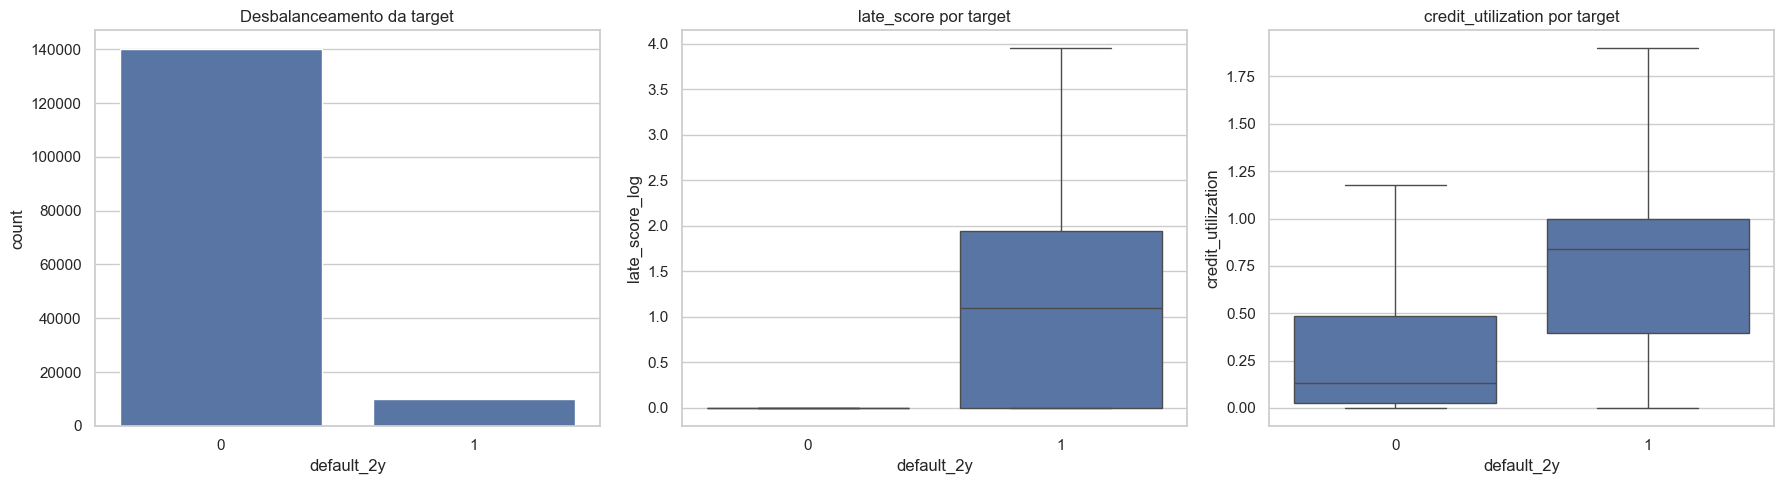

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=train_clean, x='default_2y', ax=axes[0])
axes[0].set_title('Desbalanceamento da target')

sns.boxplot(data=train_clean.assign(late_score_log=np.log1p(train_clean['late_score'])), x='default_2y', y='late_score_log', ax=axes[1], showfliers=False)
axes[1].set_title('late_score por target')

sns.boxplot(data=train_clean, x='default_2y', y='credit_utilization', ax=axes[2], showfliers=False)
axes[2].set_title('credit_utilization por target')

plt.tight_layout()
plt.show()

## 5. Conjunto final de variaveis

Baseado na analise anterior, vou utilizar as variaveis abaixo:

- `age`
- `debt_ratio`
- `monthly_income`
- `real_estate_loans`
- `dependents`
- `late_score`
- indicadores de faltantes para renda e dependentes

In [7]:
features = [
    'age',
    'debt_ratio',
    'monthly_income',
    'real_estate_loans',
    'dependents',
    'late_score',
    'monthly_income_missing',
    'dependents_missing'
]

target = 'default_2y'

X = train_clean[features].copy()
y = train_clean[target].copy()

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_valid.shape

((120000, 8), (30000, 8))

## 6. Modelo 1 - GLM Logit do statsmodels


In [8]:
X_train_glm = sm.add_constant(X_train, has_constant='add')
X_valid_glm = sm.add_constant(X_valid, has_constant='add')

glm_logit = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial()).fit()

pred_glm_train = glm_logit.predict(X_train_glm)
pred_glm_valid = glm_logit.predict(X_valid_glm)

bin_glm_train = (pred_glm_train >= 0.5).astype(int)
bin_glm_valid = (pred_glm_valid >= 0.5).astype(int)

print(glm_logit.summary())
print('\nGLM Logit - treino')
print('Acuracia:', round(accuracy_score(y_train, bin_glm_train), 3))
print('AUC:', round(roc_auc_score(y_train, pred_glm_train), 3))
print('\nGLM Logit - validacao')
print('Acuracia:', round(accuracy_score(y_valid, bin_glm_valid), 3))
print('AUC:', round(roc_auc_score(y_valid, pred_glm_valid), 3))

                 Generalized Linear Model Regression Results                  
Dep. Variable:             default_2y   No. Observations:               120000
Model:                            GLM   Df Residuals:                   119991
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -28291.
Date:                Mon, 27 Apr 2026   Deviance:                       56582.
Time:                        03:42:53   Pearson chi2:                 2.94e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01908
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -1

## 7. Modelo 2 - Regressao Logistica regularizada


In [9]:
logit_sklearn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs'
    ))
])

logit_sklearn.fit(X_train, y_train)

pred_lr_train = logit_sklearn.predict_proba(X_train)[:, 1]
pred_lr_valid = logit_sklearn.predict_proba(X_valid)[:, 1]

bin_lr_train = (pred_lr_train >= 0.5).astype(int)
bin_lr_valid = (pred_lr_valid >= 0.5).astype(int)

print('Logistic Regression - treino')
print('Acuracia:', round(accuracy_score(y_train, bin_lr_train), 3))
print('AUC:', round(roc_auc_score(y_train, pred_lr_train), 3))
print('\nLogistic Regression - validacao')
print('Acuracia:', round(accuracy_score(y_valid, bin_lr_valid), 3))
print('AUC:', round(roc_auc_score(y_valid, pred_lr_valid), 3))

Logistic Regression - treino
Acuracia: 0.758
AUC: 0.79

Logistic Regression - validacao
Acuracia: 0.761
AUC: 0.798


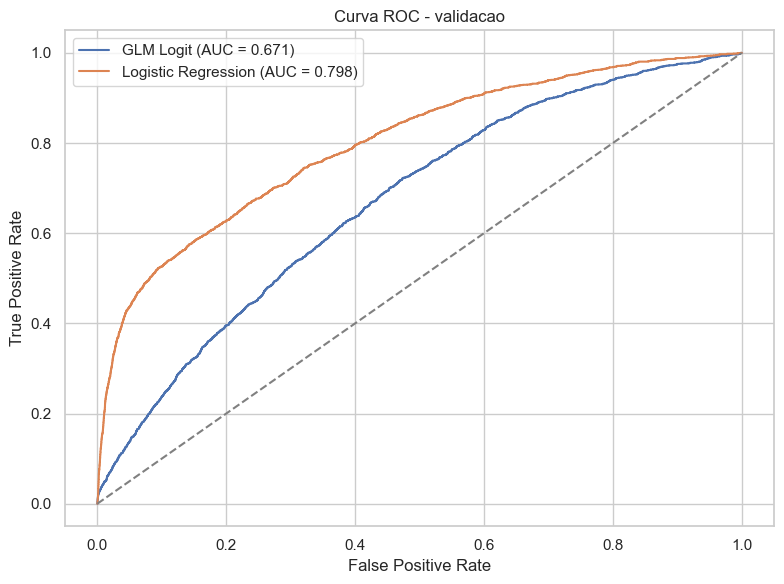

In [10]:
fpr_glm, tpr_glm, _ = roc_curve(y_valid, pred_glm_valid)
fpr_lr, tpr_lr, _ = roc_curve(y_valid, pred_lr_valid)

plt.figure(figsize=(8, 6))
plt.plot(fpr_glm, tpr_glm, label=f'GLM Logit (AUC = {roc_auc_score(y_valid, pred_glm_valid):.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_valid, pred_lr_valid):.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - validacao')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Comparacao de estrategias de selecao de variaveis

Nesta secao comparo tres abordagens para definir o conjunto de variaveis:

- selecao manual, guiada por interpretacao e EDA;
- selecao stepwise com AIC;
- selecao automatica via regressao logistica com regularizacao L1.



In [11]:
def stepwise_aic(X, y, verbose=False):
    X = X.copy()
    X = sm.add_constant(X, has_constant='add')
    included = []
    best_aic = float('inf')

    while True:
        changed = False
        excluded = list(set(X.columns) - set(included) - {'const'})
        candidates = []

        for new_col in excluded:
            try:
                model = sm.GLM(y, X[['const'] + included + [new_col]], family=sm.families.Binomial()).fit()
                candidates.append((model.aic, new_col, 'add'))
            except Exception:
                continue

        for remove_col in included:
            try:
                vars_test = [var for var in included if var != remove_col]
                model = sm.GLM(y, X[['const'] + vars_test], family=sm.families.Binomial()).fit()
                candidates.append((model.aic, remove_col, 'remove'))
            except Exception:
                continue

        if candidates:
            candidates.sort()
            best_candidate_aic, best_candidate_var, action = candidates[0]
            if best_candidate_aic < best_aic:
                changed = True
                best_aic = best_candidate_aic
                if action == 'add':
                    included.append(best_candidate_var)
                else:
                    included.remove(best_candidate_var)

        if not changed:
            break

    return included

manual_features = features.copy()
stepwise_features = stepwise_aic(X_train, y_train, verbose=False)

l1_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        random_state=42,
        class_weight='balanced',
        penalty='l1',
        solver='saga',
        max_iter=2000,
        C=1.0
    ))
])

l1_pipe.fit(X_train[manual_features], y_train)
coef_l1 = pd.Series(l1_pipe.named_steps['model'].coef_[0], index=manual_features)
l1_features = coef_l1[coef_l1.abs() > 1e-8].index.tolist()

print('Variaveis - manual:', manual_features)
print('Variaveis - stepwise AIC:', stepwise_features)
print('Variaveis - L1:', l1_features)


C:\Users\Pichau\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Pichau\.pyenv\pyenv-win\versions\3.11.9\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Variaveis - manual: ['age', 'debt_ratio', 'monthly_income', 'real_estate_loans', 'dependents', 'late_score', 'monthly_income_missing', 'dependents_missing']
Variaveis - stepwise AIC: ['age', 'late_score', 'dependents', 'monthly_income', 'dependents_missing', 'real_estate_loans', 'debt_ratio']
Variaveis - L1: ['age', 'debt_ratio', 'monthly_income', 'real_estate_loans', 'dependents', 'late_score', 'monthly_income_missing', 'dependents_missing']


In [12]:
def avaliar_glm(feature_list, nome):
    Xtr = sm.add_constant(X_train[feature_list], has_constant='add')
    Xva = sm.add_constant(X_valid[feature_list], has_constant='add')
    model = sm.GLM(y_train, Xtr, family=sm.families.Binomial()).fit()
    pred_train = model.predict(Xtr)
    pred_valid = model.predict(Xva)
    bin_valid = (pred_valid >= 0.5).astype(int)
    return {
        'abordagem': nome,
        'modelo': 'GLM Logit',
        'n_variaveis': len(feature_list),
        'auc_treino': roc_auc_score(y_train, pred_train),
        'auc_validacao': roc_auc_score(y_valid, pred_valid),
        'acuracia_validacao': accuracy_score(y_valid, bin_valid)
    }

resultados = []
resultados.append(avaliar_glm(manual_features, 'Manual'))
resultados.append(avaliar_glm(stepwise_features, 'Stepwise AIC'))

pred_l1_train = l1_pipe.predict_proba(X_train[manual_features])[:, 1]
pred_l1_valid = l1_pipe.predict_proba(X_valid[manual_features])[:, 1]
bin_l1_valid = (pred_l1_valid >= 0.5).astype(int)

resultados.append({
    'abordagem': 'L1',
    'modelo': 'Logistic Regression',
    'n_variaveis': len(l1_features),
    'auc_treino': roc_auc_score(y_train, pred_l1_train),
    'auc_validacao': roc_auc_score(y_valid, pred_l1_valid),
    'acuracia_validacao': accuracy_score(y_valid, bin_l1_valid)
})

comparacao = pd.DataFrame(resultados).sort_values('auc_validacao', ascending=False)
comparacao[['auc_treino', 'auc_validacao', 'acuracia_validacao']] = comparacao[['auc_treino', 'auc_validacao', 'acuracia_validacao']].round(3)
comparacao


,abordagem,modelo,n_variaveis,auc_treino,auc_validacao,acuracia_validacao
2,L1,Logistic Regression,8,0.789,0.798,0.760
1,Stepwise AIC,GLM Logit,7,0.655,0.671,0.933
0,Manual,GLM Logit,8,0.655,0.671,0.933
